## Importation des bibliotheques

In [16]:
import os, sys
# sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))

# biblio pour le DL
import torch
# manipulation des tab de donnees numeriques
import numpy as np
import pandas as pd
# pour les matrices
import scipy.sparse as sp
# graphiques
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
# biblio de visualisation
import seaborn as sns

# on importe les fonctions des autres fichiers
from data_utils import load_movielens_data, create_adjusted_adjacency
from model import LightGCN
from train import train_one_epoch
from evaluation import evaluate_model


# Configuration graphique
# fond blanc, grille et couleurs douces
sns.set_theme(style="whitegrid", palette="muted")
# on met la taille des graphiques a 10x5 et la police a 11
plt.rcParams.update({'figure.figsize': (10, 5), 'font.size': 11})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Périphérique actif : {device}")



Périphérique actif : cpu


In [17]:
output_dir = "Images"
os.makedirs(output_dir, exist_ok=True)

In [18]:
# Chargement brut des données (AVANT filtrage, pour l'EDA)

# on charge le fichier 
RAW_PATH = os.path.join('ml-latest-small', 'ratings.csv')
df   = pd.read_csv(RAW_PATH)

print("=" * 55)
print("  ANALYSE EXPLORATOIRE DES DONNÉES (EDA)")
print("=" * 55)

print(f"\n  Dimensions brutes : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

print(f"  Utilisateurs uniques : {df['userId'].nunique():,}")
print(f"  Films uniques : {df['movieId'].nunique():,}")

# note la plus basse et la plus grande
print(f"  Plage de notes : min : {df['rating'].min()} => max : {df['rating'].max()}")
# .sum() compte les cases vides par colonne et .sum() fait le total
print(f"  Valeurs manquantes : {df.isnull().sum().sum()}")


  ANALYSE EXPLORATOIRE DES DONNÉES (EDA)

  Dimensions brutes : 100,836 lignes × 4 colonnes
  Utilisateurs uniques : 610
  Films uniques : 9,724
  Plage de notes : min : 0.5 => max : 5.0
  Valeurs manquantes : 0


In [19]:
# Densité du graphe biparti
 
# On divise le nombre de notes existantes 
# par le nombre maximum de connexions possibles (utilisateurs x films)

density = len(df) / (df['userId'].nunique() * df['movieId'].nunique())
print(f"  Densité du graphe : {density*100:.3f} %")
print(f"  Note moyenne globale : {df['rating'].mean():.2f}")
print(f"  Médiane des notes : {df['rating'].median():.1f}")

  Densité du graphe : 1.700 %
  Note moyenne globale : 3.50
  Médiane des notes : 3.5


Dans la réalité, cette densité est souvent très faible (souvent inférieure à 1 % ou 2 %). C'est ce qu'on appelle ** le problème de la matrice creuse (sparsity) ** : un utilisateur ne peut pas voir tous les films de la terre

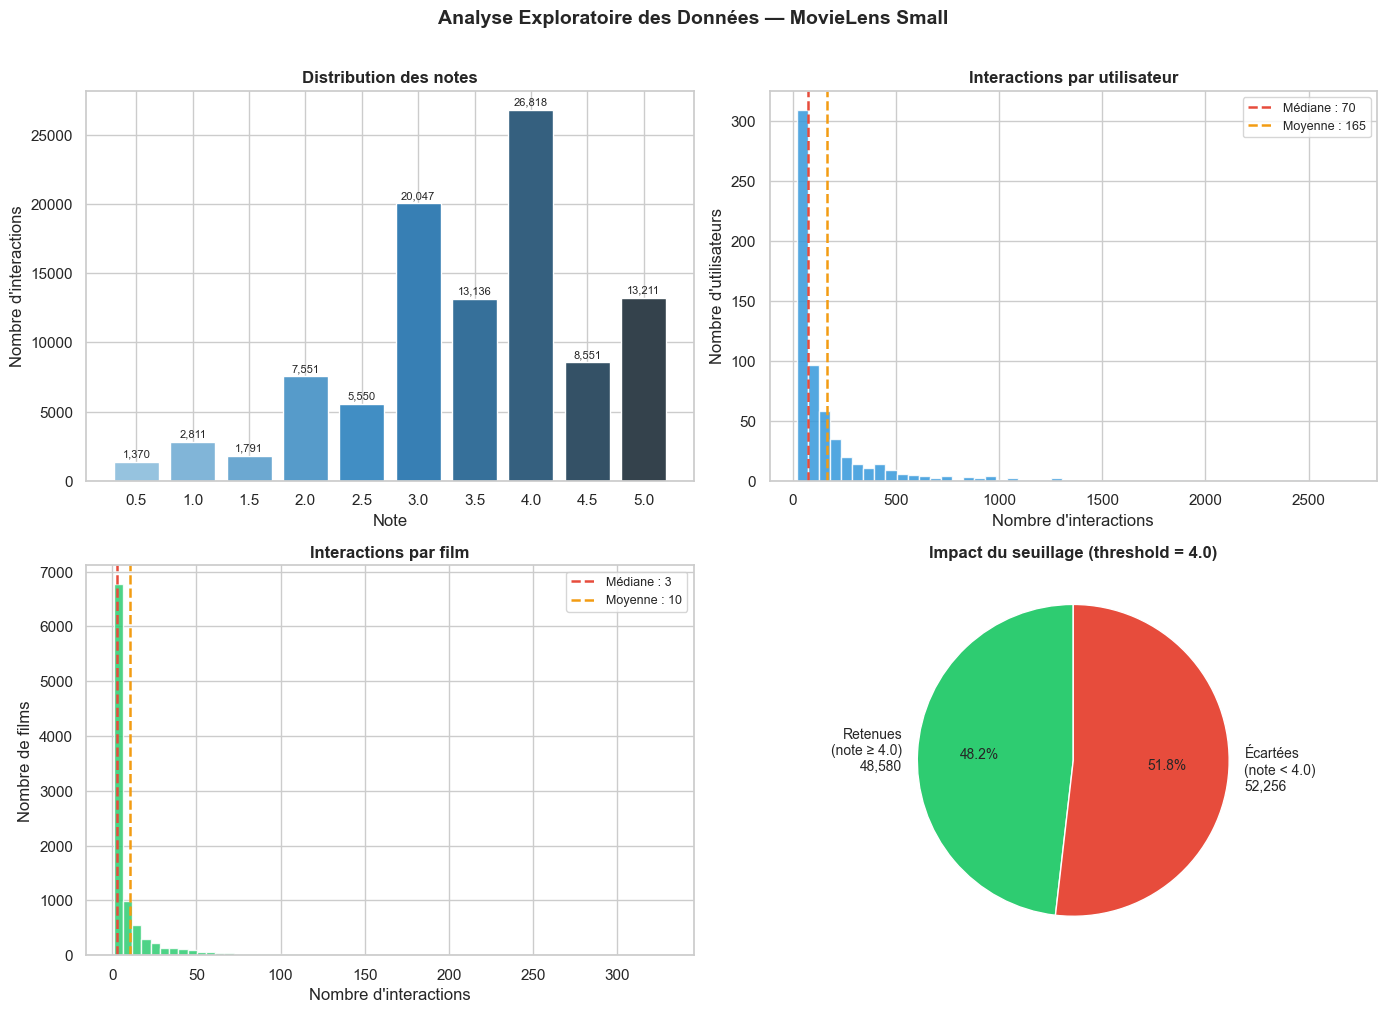

In [20]:
# EDA : Visualisations exploratoires

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Analyse Exploratoire des Données — MovieLens Small", fontsize=14, fontweight='bold', y=1.01)

# Distribution des notes 
ax = axes[0, 0]
note_counts = df['rating'].value_counts().sort_index()
bars = ax.bar(note_counts.index.astype(str), note_counts.values, color=sns.color_palette("Blues_d", len(note_counts)))
ax.set_title("Distribution des notes", fontweight='bold')
ax.set_xlabel("Note")
ax.set_ylabel("Nombre d'interactions")
for bar, val in zip(bars, note_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f'{val:,}',
            ha='center', va='bottom', fontsize=8)

# Interactions par utilisateur (distribution log)
# nombre de films notes par chaque utilisateur unique.
ax = axes[0, 1]
user_counts = df.groupby('userId').size()
ax.hist(user_counts, bins=50, color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(user_counts.median(), color='#e74c3c', linestyle='--', linewidth=1.8, label=f'Médiane : {user_counts.median():.0f}')
ax.axvline(user_counts.mean(),   color='#f39c12', linestyle='--', linewidth=1.8, label=f'Moyenne : {user_counts.mean():.0f}')
ax.set_title("Interactions par utilisateur", fontweight='bold')
ax.set_xlabel("Nombre d'interactions")
ax.set_ylabel("Nombre d'utilisateurs")
ax.legend(fontsize=9)

# Interactions par film (distribution log) 
# on visualise la popularite des films
ax = axes[1, 0]
item_counts = df.groupby('movieId').size()
ax.hist(item_counts, bins=60, color='#2ecc71', edgecolor='white', alpha=0.85)
ax.axvline(item_counts.median(), color='#e74c3c', linestyle='--', linewidth=1.8, label=f'Médiane : {item_counts.median():.0f}')
ax.axvline(item_counts.mean(),   color='#f39c12', linestyle='--', linewidth=1.8, label=f'Moyenne : {item_counts.mean():.0f}')
ax.set_title("Interactions par film", fontweight='bold')
ax.set_xlabel("Nombre d'interactions")
ax.set_ylabel("Nombre de films")
ax.legend(fontsize=9)

# Proportion des notes retenues après seuillage 
ax = axes[1, 1]
threshold = 4.0 # on definti le seuil
kept    = (df['rating'] >= threshold).sum()
dropped = len(df) - kept
ax.pie(
    [kept, dropped],
    labels=[f'Retenues\n(note ≥ {threshold})\n{kept:,}', f'Écartées\n(note < {threshold})\n{dropped:,}'],
    colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 10}
)
ax.set_title(f"Impact du seuillage (threshold = {threshold})", fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "eda_movielens.png"), dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# EDA : Statistiques post-filtrage + structure du graphe biparti

# on cree un df ou la note min est 4.0 (note d'appreciation)
filtered_df = df[df['rating'] >= 4.0].copy()

print("\n" + "=" * 55)
print("  STATISTIQUES DE VOLUME POST-FILTRAGE (seuil ≥ 4.0)")
print("=" * 55)

print(f"  Interactions retenues : {len(filtered_df):,} / {len(df):,}")
print(f"  Utilisateurs actifs : {filtered_df['userId'].nunique():,}")
print(f"  Films notés positivement : {filtered_df['movieId'].nunique():,}")

# analyse des deres
# le nbre de films que chaque user a aime
user_deg = filtered_df.groupby('userId').size()
# combien de fois chaque film a ete aime
item_deg = filtered_df.groupby('movieId').size()
print(f"\n  Degré utilisateur — min: {user_deg.min()}, max: {user_deg.max()}, "
      f"moyenne: {user_deg.mean():.1f}, médiane: {user_deg.median():.0f}")
print(f"  Degré film — min: {item_deg.min()}, max: {item_deg.max()}, "
      f"moyenne: {item_deg.mean():.1f}, médiane: {item_deg.median():.0f}")

# Probleme du cold-start : utilisateurs avec tres peu d'interactions
# on cree une liste de booleens pour reperer les utilisateurs qui n'ont valide que 2 films ou moins
cold_users = (user_deg <= 2).sum()
cold_items = (item_deg <= 2).sum()
print(f"\n  Utilisateurs cold-start (≤ 2 interactions) : {cold_users} ({cold_users/len(user_deg)*100:.1f} %)")
print(f"  Films cold-start (≤ 2 interactions) : {cold_items} ({cold_items/len(item_deg)*100:.1f} %)")


  STATISTIQUES DE VOLUME POST-FILTRAGE (seuil ≥ 4.0)
  Interactions retenues : 48,580 / 100,836
  Utilisateurs actifs : 609
  Films notés positivement : 6,298

  Degré utilisateur — min: 1, max: 1227, moyenne: 79.8, médiane: 40
  Degré film — min: 1, max: 274, moyenne: 7.7, médiane: 2

  Utilisateurs cold-start (≤ 2 interactions) : 1 (0.2 %)
  Films cold-start (≤ 2 interactions) : 3488 (55.4 %)


### Le phénomène de Cold-Start est la bête noire des systèmes de recommandation : il est très difficile de recommander des films à quelqu'un dont on ne sait presque rien, ou de recommander un film qui n'a presque pas de notes.


## Preparation des donnees
 

In [22]:
# Chargement pour l'entraînement + construction du graphe

train_df, test_df, num_users, num_items = load_movielens_data('ml-latest-small')
# matrice d'adjacence symetrique (matrice normalisee)
norm_adj = create_adjusted_adjacency(train_df, num_users, num_items).to(device)

print(f"\nGraphe biparti prêt : {num_users} utilisateurs | {num_items} films")
print(f"Arêtes dans le graphe (train) : {len(train_df):,}")

  Interactions totales : 48,580  →  Train : 39,100  |  Test : 9,480

Graphe biparti prêt : 609 utilisateurs | 6298 films
Arêtes dans le graphe (train) : 39,100


In [23]:
# Instanciation du modèle LightGCN

# chaque film va etre prepresente par un vecteur de nbre de taille 64
EMBEDDING_DIM = 64
NUM_LAYERS  = 3
LR = 0.005
EPOCHS  = 20
# coef de regularisation (regul L2), empeche les valeurs des embeddings de devenir trop grandes
LAMBDA_REG = 1e-4
BATCH_SIZE  = 1024
# les meilleurs recommandations de films pour chaque user
TOP_K = 20

model     = LightGCN(num_users, num_items, EMBEDDING_DIM, NUM_LAYERS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

total_params = sum(p.numel() for p in model.parameters())
print(f"Modèle LightGCN — {total_params:,} paramètres entraînables")
print(f"Architecture : {NUM_LAYERS} couches de Message Passing | dim = {EMBEDDING_DIM}")

Modèle LightGCN — 442,048 paramètres entraînables
Architecture : 3 couches de Message Passing | dim = 64


## Entrainement

In [ ]:
# Boucle d'entraînement avec collecte complete des métriques

# - La loss est enregistree a chaque epoque 
# - Les metriques Recall/NDCG sont enregistrees aux epoques d'evaluation

all_epochs = []          
all_losses = [] # BPR loss 

eval_epochs = []          # epoques ou l'eval a eu lieu
eval_recalls = []          # son recalls
eval_ndcgs = []          # son NDCG@K 

EVAL_EVERY = 2  # frequence d'eval

print(f"\n===> Entraînement ({EPOCHS} époques, évaluation toutes les {EVAL_EVERY} époques)\n")
print(f"  {'Époque':>6}  {'BPR Loss':>10}  {'Recall@20':>10}  {'NDCG@20':>10}")
print("  " + "─" * 42)

for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch(
        model, norm_adj, train_df, num_items, optimizer,
        lambda_reg=LAMBDA_REG, batch_size=BATCH_SIZE
    )
    all_epochs.append(epoch)
    all_losses.append(loss)

    if epoch == 1 or epoch % EVAL_EVERY == 0:
        recall, ndcg = evaluate_model(model, norm_adj, train_df, test_df, k=TOP_K)
        eval_epochs.append(epoch)
        eval_recalls.append(recall)
        eval_ndcgs.append(ndcg)
        print(f"  {epoch:>4}/{EPOCHS}  {loss:>10.4f}  {recall*100:>9.2f}%  {ndcg*100:>9.2f}%")
    else:
        print(f"  {epoch:>4}/{EPOCHS}  {loss:>10.4f}")


===> Entraînement (20 époques, évaluation toutes les 2 époques)

  Époque    BPR Loss   Recall@20     NDCG@20
  ──────────────────────────────────────────
     1/20      0.6929      16.58%      16.08%
     2/20      0.6176      15.76%      15.62%
     3/20      0.3542
     4/20      0.2679      20.04%      18.56%
     5/20      0.2268
     6/20      0.1898      20.91%      19.53%
     7/20      0.1742
     8/20      0.1569      20.67%      19.63%
     9/20      0.1472
    10/20      0.1420      21.58%      20.12%
    11/20      0.1298
    12/20      0.1239      21.54%      20.41%
    13/20      0.1182
    14/20      0.1139      21.75%      20.43%
    15/20      0.1056
    16/20      0.1025      22.04%      20.94%
    17/20      0.0984
    18/20      0.0937      22.55%      21.29%
    19/20      0.0906
    20/20      0.0853      22.49%      21.44%


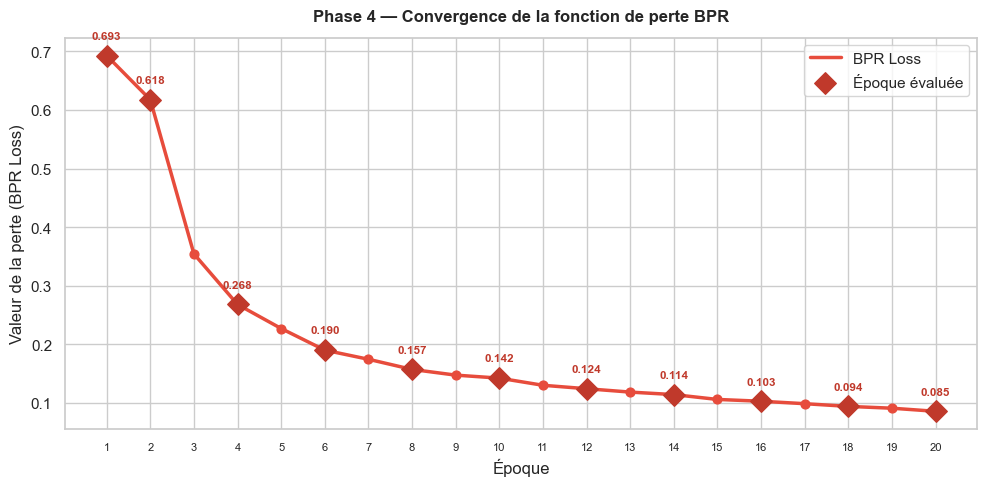

In [25]:
# Convergence de la perte BPR 
# on verifie que le modele apprend corectement (elle doit descendre)

fig, ax = plt.subplots(figsize=(10, 5))

# on relie tous les points par une ligne rouge
ax.plot(all_epochs, all_losses, color='#e74c3c', linewidth=2.5, label='BPR Loss')
# on ajoute un petit point rodn sur chaq epoque pour marquer la perte de chaque etape
ax.scatter(all_epochs, all_losses, color='#e74c3c', s=40, zorder=5)

# Marqueurs aux epoques evaluees
eval_losses = [all_losses[e-1] for e in eval_epochs]
# on dessien un losange au dessus des points pour identifier a quel moment les metriques Recall et NDCG ont ete calculees 
ax.scatter(eval_epochs, eval_losses, color='#c0392b', s=120, zorder=6,
           marker='D', label='Époque évaluée')

# Annotations aux époques evaluees 
for x, y in zip(eval_epochs, eval_losses):
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                xytext=(0, 12), ha='center', fontsize=8.5, fontweight='bold', color='#c0392b')

ax.set_title("Phase 4 — Convergence de la fonction de perte BPR", fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel("Époque")
ax.set_ylabel("Valeur de la perte (BPR Loss)")
ax.set_xticks(all_epochs) # on affiche les graduations par epoque
ax.tick_params(axis='x', labelsize=8)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "loss_curve.png"), dpi=150, bbox_inches='tight')
plt.show()

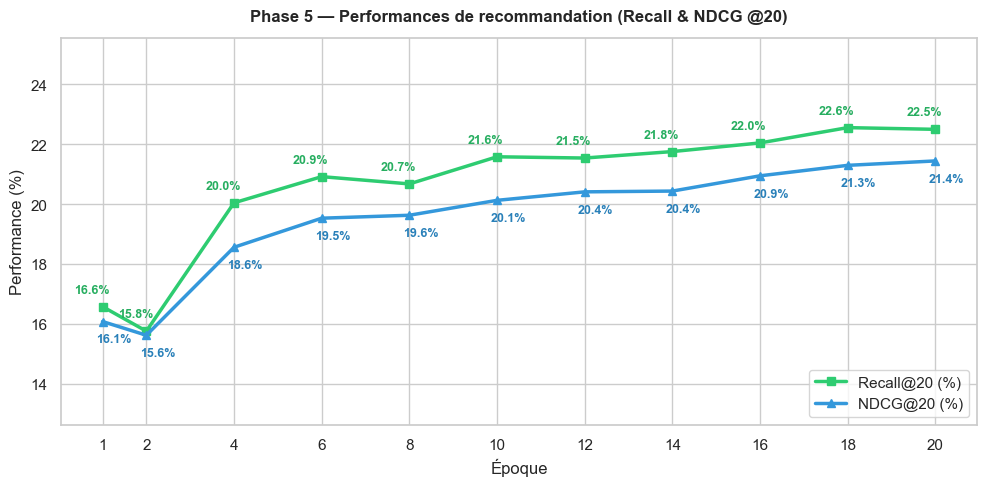

In [26]:

# Evolution de Recall@K et NDCG@K

fig, ax = plt.subplots(figsize=(10, 5))

# pourcentage
recall_pct = [r * 100 for r in eval_recalls]
ndcg_pct   = [n * 100 for n in eval_ndcgs]

# capacite du modele a retrouver les fimls aimees par les users
ax.plot(eval_epochs, recall_pct, marker='s', color='#2ecc71', linewidth=2.5, label=f'Recall@{TOP_K} (%)')
# evolution de la qualite du classement des recommandations
ax.plot(eval_epochs, ndcg_pct,   marker='^', color='#3498db', linewidth=2.5, label=f'NDCG@{TOP_K} (%)')

# Recall (au-dessus) et NDCG (en-dessous)
for x, y in zip(eval_epochs, recall_pct):
    ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points",
                xytext=(-8, 10), ha='center', color='#27ae60', fontsize=9, fontweight='bold')
for x, y in zip(eval_epochs, ndcg_pct):
    ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points",
                xytext=(8, -15), ha='center', color='#2980b9', fontsize=9, fontweight='bold')

margin = 3
ax.set_ylim(min(ndcg_pct) - margin, max(recall_pct) + margin)
ax.set_xticks(eval_epochs)
ax.set_title(f"Phase 5 — Performances de recommandation (Recall & NDCG @{TOP_K})",
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel("Époque")
ax.set_ylabel("Performance (%)")
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "metrics_curve.png"), dpi=150, bbox_inches='tight')
plt.show()

### on extrait les vecteurs de caracteristiques pour voir si l emodele a reussi a regrouper les users ayant des gouts similaires

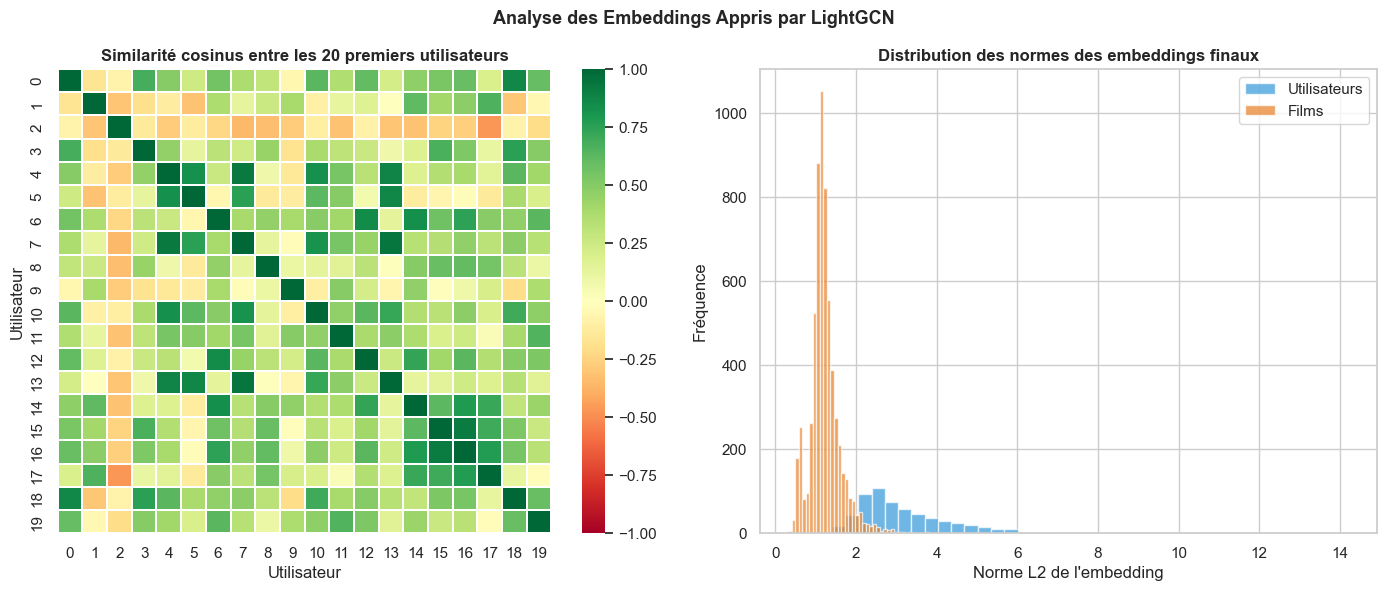

Figure sauvegardée : embedding_analysis.png


In [27]:
# Analyse des embeddings appris (similarite cosinus dans l'espace latent)

model.eval()
with torch.no_grad():
    users_final, items_final = model(norm_adj) # forward pass

users_np = users_final.cpu().numpy() # (num_users, d)
items_np = items_final.cpu().numpy() # (num_items, d)

# Normalisation L2 pour la similarite cosinus
def l2_normalize(X):
    # longueur geometrique
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    # On evite la devision par 0
    return X / (norms + 1e-8)

users_norm = l2_normalize(users_np)
items_norm = l2_normalize(items_np)

# Heatmap de similarite entre les 20 premiers utilisateurs 
N_USERS_DISPLAY = 20
# on multiplie la matrices des 20 users par sa transposee 
# la case (i, j) represente la ressemblance entre l'utilisateur i et l'utilisateur j

sim_matrix = users_norm[:N_USERS_DISPLAY] @ users_norm[:N_USERS_DISPLAY].T

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Analyse des Embeddings Appris par LightGCN", fontsize=13, fontweight='bold')

# graphique - heatmap de similarite
ax = axes[0]
sns.heatmap(sim_matrix, ax=ax, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            xticklabels=range(N_USERS_DISPLAY), yticklabels=range(N_USERS_DISPLAY),
            linewidths=0.3, linecolor='white')
ax.set_title(f"Similarité cosinus entre les {N_USERS_DISPLAY} premiers utilisateurs", fontweight='bold')
ax.set_xlabel("Utilisateur")
ax.set_ylabel("Utilisateur")

# Distribution des normes des embeddings utilisateurs
ax = axes[1]
user_norms = np.linalg.norm(users_np, axis=1)
item_norms = np.linalg.norm(items_np, axis=1)
ax.hist(user_norms, bins=40, alpha=0.7, color='#3498db', label='Utilisateurs', edgecolor='white')
ax.hist(item_norms, bins=40, alpha=0.7, color='#e67e22', label='Films',         edgecolor='white')
ax.set_title("Distribution des normes des embeddings finaux", fontweight='bold')
ax.set_xlabel("Norme L2 de l'embedding")
ax.set_ylabel("Fréquence")
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "embedding_analysis.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : embedding_analysis.png")

In [28]:
# Résumé final et interprétation des résultats

final_recall = eval_recalls[-1]
final_ndcg   = eval_ndcgs[-1]
final_loss   = all_losses[-1]
loss_drop    = (all_losses[0] - final_loss) / all_losses[0] * 100

print("\n" + "=" * 60)
print("  RÉSUMÉ ET INTERPRÉTATION DES RÉSULTATS")
print("=" * 60)

print(f"""

  BPR Loss finale : {final_loss:.4f}  (−{loss_drop:.1f} % vs époque 1)  \n
  Recall@{TOP_K} : {final_recall*100:.2f} %  \n                        
  NDCG@{TOP_K} : {final_ndcg*100:.2f} %  \n                        
""")


  RÉSUMÉ ET INTERPRÉTATION DES RÉSULTATS


  BPR Loss finale : 0.0853  (−87.7 % vs époque 1)  

  Recall@20 : 22.49 %  
                        
  NDCG@20 : 21.44 %  
                        



  • BPR Loss ({final_loss:.4f}) : La décroissance de la loss confirme que le modèle
    apprend à distinguer les articles pertinents des non-pertinents. Une loss
    qui se stabilise en fin d'entraînement indique la convergence.

  • Recall@{TOP_K} ({final_recall*100:.1f} %) : Sur l'ensemble des films aimés par un
    utilisateur dans le test, {final_recall*100:.1f} % se retrouvent dans les Top-{TOP_K}
    recommandations. Sur MovieLens-small, des valeurs entre 5 % et 20 %
    sont typiques pour un LightGCN entraîné 20 époques.

  • NDCG@{TOP_K} ({final_ndcg*100:.1f} %) : Mesure la qualité du classement.
    Un NDCG élevé signifie que les films pertinents apparaissent en tête
    de liste. NDCG < Recall est normal car il pénalise les bons articles
    placés en bas de liste.

  LIMITES CONNUES DE CETTE CONFIGURATION :
  • 20 époques est insuffisant pour la convergence optimale (50-100 recommandé).
  • Le cold-start (utilisateurs avec peu d'interactions) reste non traité.
  • L'échantillonnage négatif uniforme peut être amélioré (pop-based sampling).